# Forecast Pertumbuhan Ekonomi Indonesia (YoY)

**Tujuan:** memprediksi pertumbuhan ekonomi (%, year-on-year) untuk kuartal 2, 3, dan 4 tahun 2026, menggunakan data historis kuartalan 2011Q1–2026Q1 (BPS).

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RANDOM_STATE = 42

## 1. Load Data


In [4]:
DATA_PATH = "../data/raw/groupA/usecase_ekonomi.ekonomi_pertumbuhan_ekonomi_kuartal_2010_2026.csv"

df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (61, 5)


,id,tahun,kuartal,growth_pct,data_source
0,1,2011,1,6.48,https://www.bps.go.id/id/statistics-table/2/MT...
1,2,2011,2,6.27,https://www.bps.go.id/id/statistics-table/2/MT...
2,3,2011,3,6.01,https://www.bps.go.id/id/statistics-table/2/MT...
3,4,2011,4,5.94,https://www.bps.go.id/id/statistics-table/2/MT...
4,5,2012,1,6.11,https://www.bps.go.id/id/statistics-table/2/MT...


In [5]:
df_raw.info()
print()
print("Missing values per kolom:")
print(df_raw.isnull().sum())
print()
print("Duplicate rows:", df_raw.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           61 non-null     int64  
 1   tahun        61 non-null     int64  
 2   kuartal      61 non-null     int64  
 3   growth_pct   61 non-null     float64
 4   data_source  61 non-null     object 
dtypes: float64(1), int64(3), object(1)
memory usage: 2.5+ KB

Missing values per kolom:
id             0
tahun          0
kuartal        0
growth_pct     0
data_source    0
dtype: int64

Duplicate rows: 0


## 2. Preprocessing

- Urutkan berdasarkan tahun & kuartal (jaga-jaga kalau ada yang belum urut)
- Buat `PeriodIndex` kuartalan supaya time series-nya punya index yang benar (bukan cuma index integer biasa) — ini penting untuk model statsmodels/pmdarima yang butuh info frekuensi
- Cek gap kuartal (ada quarter yang bolong nggak)
- Cek outlier/anomali (kita tau ada shock COVID di 2020, itu valid dan bukan data error, jadi kita **nggak** akan hapus/impute itu)

In [6]:
df = df_raw.copy()
df = df.sort_values(['tahun', 'kuartal']).reset_index(drop=True)

df['period'] = pd.PeriodIndex.from_fields(year=df['tahun'], quarter=df['kuartal'], freq='Q')

# cek continuity kuartal (harus naik 1 kuartal terus, tanpa gap)
expected = pd.period_range(df['period'].min(), df['period'].max(), freq='Q')
missing_periods = set(expected) - set(df['period'])
print("Rentang data:", df['period'].min(), "-", df['period'].max())
print("Jumlah observasi:", len(df))
print("Kuartal yang bolong:", sorted(missing_periods) if missing_periods else "tidak ada (data lengkap & kontinu)")

Rentang data: 2011Q1 - 2026Q1
Jumlah observasi: 61
Kuartal yang bolong: tidak ada (data lengkap & kontinu)


In [7]:
series = df.set_index('period')['growth_pct'].astype(float)
series.index = series.index.to_timestamp(how='end')  # biar enak diplot, tetap quarterly
series.index.freq = 'QE-DEC'
series.name = 'growth_pct'
series.tail()

period
2025-03-31 23:59:59.999999999    4.87
2025-06-30 23:59:59.999999999    5.12
2025-09-30 23:59:59.999999999    5.04
2025-12-31 23:59:59.999999999    5.39
2026-03-31 23:59:59.999999999    5.61
Freq: QE-DEC, Name: growth_pct, dtype: float64

## 3. Exploratory Data Analysis

### 3.1 Plot deret waktu

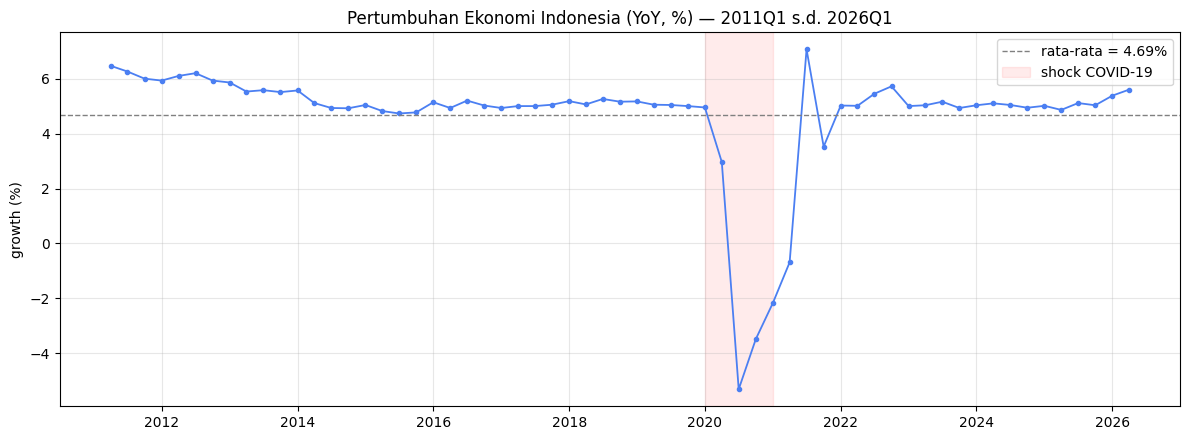

count    61.000000
mean      4.692951
std       2.161415
min      -5.320000
25%       4.950000
50%       5.050000
75%       5.460000
max       7.080000
Name: growth_pct, dtype: float64


In [8]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(series.index, series.values, marker='o', markersize=3, linewidth=1.3, color='#4B7FF2')
ax.axhline(series.mean(), color='gray', linestyle='--', linewidth=1, label=f'rata-rata = {series.mean():.2f}%')
ax.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-12-31'), color='red', alpha=0.08, label='shock COVID-19')
ax.set_title('Pertumbuhan Ekonomi Indonesia (YoY, %) — 2011Q1 s.d. 2026Q1')
ax.set_ylabel('growth (%)')
ax.legend()
plt.tight_layout()
plt.show()

print(series.describe())

Kelihatan jelas ada shock besar waktu COVID-19 (2020Q2 sampai 2021Q1), lalu recovery, dan sejak 2022 growth relatif stabil.

### 3.2 Seasonal decomposition (STL)

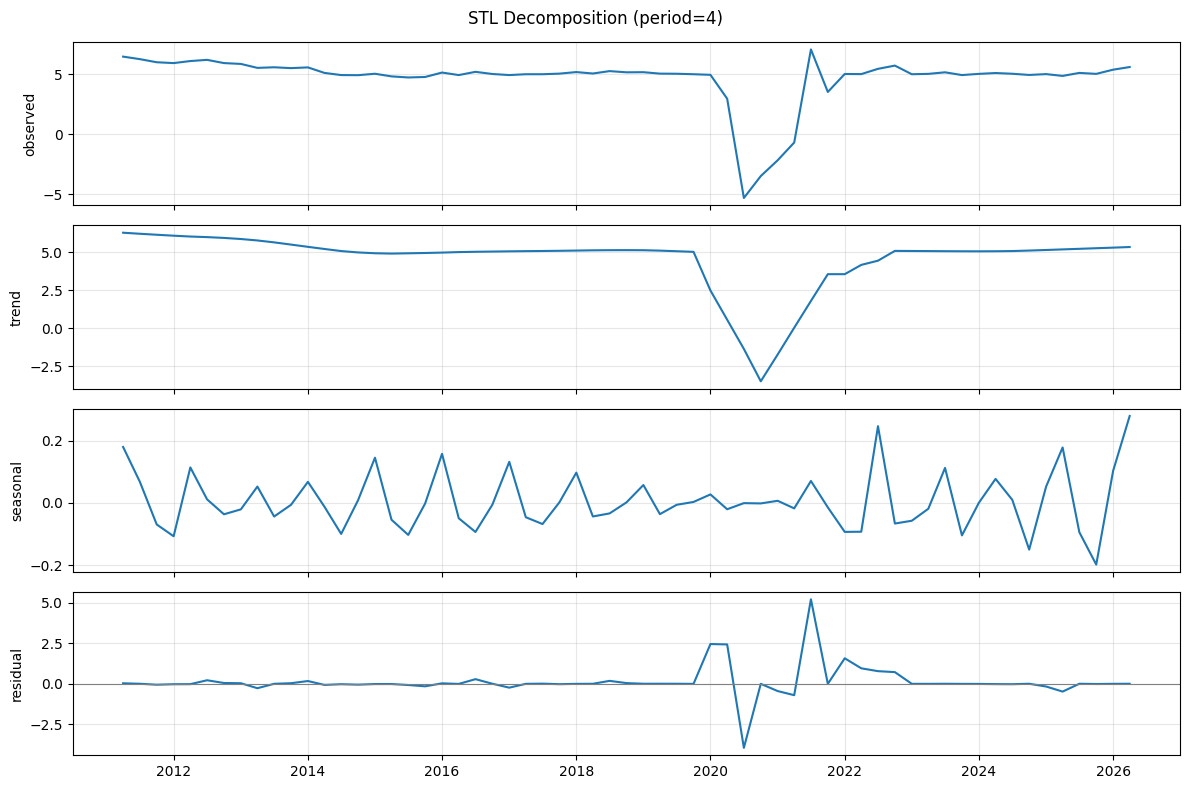

Range komponen seasonal: -0.198 s.d. 0.279


In [9]:
stl = STL(series, period=4, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(series.index, stl.observed)
axes[0].set_ylabel('observed')
axes[1].plot(series.index, stl.trend)
axes[1].set_ylabel('trend')
axes[2].plot(series.index, stl.seasonal)
axes[2].set_ylabel('seasonal')
axes[3].plot(series.index, stl.resid)
axes[3].set_ylabel('residual')
axes[3].axhline(0, color='gray', linewidth=0.8)
plt.suptitle('STL Decomposition (period=4)')
plt.tight_layout()
plt.show()

print("Range komponen seasonal:", stl.seasonal.min().round(3), "s.d.", stl.seasonal.max().round(3))

Komponen seasonal amplitudonya kecil dibanding trend & residual, mengonfirmasi dugaan awal: karena datanya sudah YoY, efek musiman kuartalan yang tersisa memang minor. Ini artinya model seasonal (SARIMA/Holt-Winters seasonal) belum tentu menang dibanding model non-seasonal

### 3.3 Uji stasioneritas (ADF & KPSS)

In [10]:
adf_stat, adf_p, *_ = adfuller(series, autolag='AIC')
print(f"ADF statistic : {adf_stat:.4f}")
print(f"ADF p-value   : {adf_p:.4f}  -> {'stasioner (tolak H0)' if adf_p < 0.05 else 'TIDAK stasioner (gagal tolak H0)'}")

print()
kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
print(f"KPSS statistic: {kpss_stat:.4f}")
print(f"KPSS p-value  : {kpss_p:.4f}  -> {'TIDAK stasioner (tolak H0)' if kpss_p < 0.05 else 'stasioner (gagal tolak H0)'}")

ADF statistic : -2.3075
ADF p-value   : 0.1696  -> TIDAK stasioner (gagal tolak H0)

KPSS statistic: 0.2161
KPSS p-value  : 0.1000  -> stasioner (gagal tolak H0)


ADF dan KPSS agak berlawanan (umum terjadi di data dengan break COVID shock), sinyal ini yang jadi alasan kenapa coba ARIMA dengan differencing `d=1` sebagai salah satu kandidat, di samping model level (ETS/Holt) yang bisa handle non-stasioneritas ringan tanpa differencing eksplisit.

### 3.4 ACF & PACF

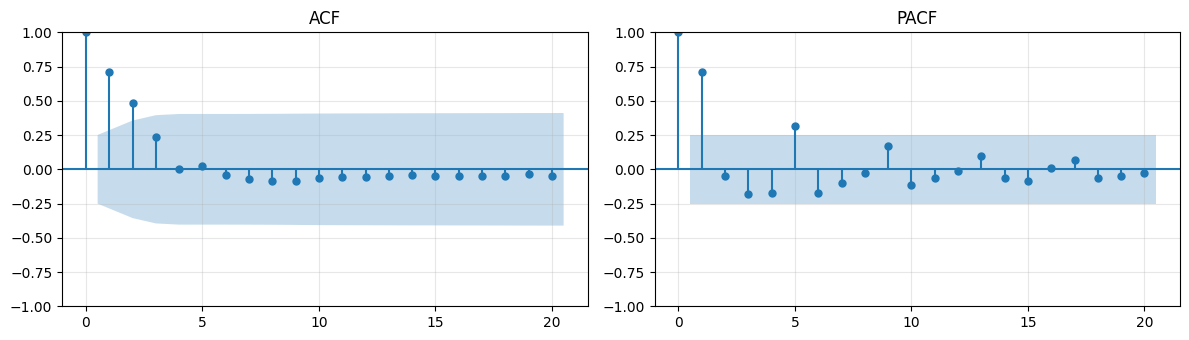

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(series, ax=axes[0], lags=20)
plot_pacf(series, ax=axes[1], lags=20, method='ywm')
axes[0].set_title('ACF')
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

PACF cut-off cepat setelah lag 1 (dengan sedikit sisa di lag musiman ke-4), konsisten dengan proses AR(1)-like — ini yang mendasari pemilihan kandidat ARIMA(1,1,1) di bawah, selain hasil `auto_arima`.

## 4. Kandidat Model

Model yang dicoba:

| Kategori | Model |
|---|---|
| Baseline | Naive (persistence), Seasonal Naive (kuartal sama tahun lalu), Moving Average 4 kuartal |
| Statistical (exponential smoothing) | Simple Exponential Smoothing (SES), Holt (damped trend), Holt-Winters (seasonal) |
| Statistical (ARIMA family) | ARIMA(1,1,1) manual, Auto-ARIMA/SARIMA (`pmdarima`, cari order optimal by AIC) |
| Machine Learning | Linear Regression (lag features), Random Forest (lag features) |


In [12]:
def make_lag_features(s: pd.Series, n_lags: int = 4) -> pd.DataFrame:
    d = pd.DataFrame({'y': s.values}, index=s.index)
    for l in range(1, n_lags + 1):
        d[f'lag{l}'] = d['y'].shift(l)
    return d.dropna()


def naive_fc(train, h):
    return np.repeat(train.iloc[-1], h)


def seasonal_naive_fc(train, h):
    base = train.iloc[-4:].values if len(train) >= 4 else train.values
    return np.array([base[i % len(base)] for i in range(h)])


def ma4_fc(train, h):
    return np.repeat(train.iloc[-4:].mean(), h)


def ses_fc(train, h):
    m = ExponentialSmoothing(train, trend=None, seasonal=None).fit()
    return m.forecast(h).values


def holt_fc(train, h):
    m = ExponentialSmoothing(train, trend='add', damped_trend=True, seasonal=None).fit()
    return m.forecast(h).values


def hw_seasonal_fc(train, h):
    m = ExponentialSmoothing(train, trend='add', damped_trend=True, seasonal='add', seasonal_periods=4).fit()
    return m.forecast(h).values


def arima_111_fc(train, h):
    m = ARIMA(train, order=(1, 1, 1)).fit()
    return m.forecast(h).values


def auto_arima_fc(train, h):
    m = pm.auto_arima(train, seasonal=True, m=4, suppress_warnings=True, error_action='ignore')
    return np.asarray(m.predict(h))


def _recursive_ml_fc(model_cls, train, h, n_lags=4, **kwargs):
    d = make_lag_features(train, n_lags=n_lags)
    X, y = d.drop(columns='y'), d['y']
    model = model_cls(**kwargs).fit(X, y)
    hist = list(train.values)
    preds = []
    for _ in range(h):
        x_new = pd.DataFrame([{f'lag{l}': hist[-l] for l in range(1, n_lags + 1)}])[X.columns]
        p = model.predict(x_new)[0]
        hist.append(p)
        preds.append(p)
    return np.array(preds)


def linreg_fc(train, h):
    return _recursive_ml_fc(LinearRegression, train, h)


def rf_fc(train, h):
    return _recursive_ml_fc(RandomForestRegressor, train, h, n_estimators=300, random_state=RANDOM_STATE)


MODELS = {
    'Naive': naive_fc,
    'SeasonalNaive': seasonal_naive_fc,
    'MovingAverage(4Q)': ma4_fc,
    'SES': ses_fc,
    'Holt(damped)': holt_fc,
    'HoltWinters(seasonal)': hw_seasonal_fc,
    'ARIMA(1,1,1)': arima_111_fc,
    'AutoARIMA/SARIMA': auto_arima_fc,
    'LinearRegression(lag)': linreg_fc,
    'RandomForest(lag)': rf_fc,
}
print(f"{len(MODELS)} model kandidat siap dites:")
for name in MODELS:
    print(" -", name)

10 model kandidat siap dites:
 - Naive
 - SeasonalNaive
 - MovingAverage(4Q)
 - SES
 - Holt(damped)
 - HoltWinters(seasonal)
 - ARIMA(1,1,1)
 - AutoARIMA/SARIMA
 - LinearRegression(lag)
 - RandomForest(lag)


## 5. Rolling-Origin Backtesting

**8 kuartal terakhir** (2024Q1–2025Q4) adalah  periode evaluasi. Untuk tiap origin di rentang itu, model di-fit ulang hanya pakai data sebelum origin tsb, lalu forecast h=1, h=2, h=3 langkah ke depan dan dibandingkan ke actual.

In [13]:
HOLDOUT_QUARTERS = 8
HORIZONS = [1, 2, 3]

n = len(series)
test_origins = list(range(n - HOLDOUT_QUARTERS, n))

def run_backtest():
    rows = []
    for model_name, fc_func in MODELS.items():
        for origin in test_origins:
            train = series.iloc[:origin]
            max_h = min(max(HORIZONS), n - origin)
            if max_h < 1:
                continue
            try:
                preds = fc_func(train, max_h)
            except Exception as e:
                preds = [np.nan] * max_h
            for h in HORIZONS:
                if h > max_h:
                    continue
                actual = series.iloc[origin + h - 1]
                pred = preds[h - 1]
                rows.append({
                    'model': model_name, 'origin': series.index[origin - 1],
                    'h': h, 'actual': actual, 'pred': pred
                })
    return pd.DataFrame(rows)

bt = run_backtest()
bt.head()

,model,origin,h,actual,pred
0,Naive,2024-03-31 23:59:59.999999999,1,5.05,5.11
1,Naive,2024-03-31 23:59:59.999999999,2,4.95,5.11
2,Naive,2024-03-31 23:59:59.999999999,3,5.02,5.11
3,Naive,2024-06-30 23:59:59.999999999,1,4.95,5.05
4,Naive,2024-06-30 23:59:59.999999999,2,5.02,5.05


In [14]:
def mae(g):  return np.mean(np.abs(g['actual'] - g['pred']))
def rmse(g): return np.sqrt(np.mean((g['actual'] - g['pred'])**2))
def mape(g): return np.mean(np.abs((g['actual'] - g['pred']) / g['actual'])) * 100

metrics = (bt.dropna(subset=['pred'])
             .groupby(['model', 'h'])
             .apply(lambda g: pd.Series({'MAE': mae(g), 'RMSE': rmse(g), 'MAPE': mape(g)}))
             .reset_index())

mae_pivot = metrics.pivot(index='model', columns='h', values='MAE').round(3)
mae_pivot.columns = [f'h={h}' for h in mae_pivot.columns]
mae_pivot['avg_MAE'] = mae_pivot.mean(axis=1)
mae_pivot = mae_pivot.sort_values('avg_MAE')
mae_pivot

,h=1,h=2,h=3,avg_MAE
model,,,,
MovingAverage(4Q),0.170,0.207,0.223,0.200000
"ARIMA(1,1,1)",0.156,0.199,0.247,0.200667
Naive,0.160,0.197,0.245,0.200667
SES,0.157,0.200,0.245,0.200667
Holt(damped),0.156,0.200,0.250,0.202000
HoltWinters(seasonal),0.145,0.208,0.260,0.204333
SeasonalNaive,0.208,0.220,0.255,0.227667
RandomForest(lag),0.167,0.458,0.397,0.340667
AutoARIMA/SARIMA,0.509,0.353,0.499,0.453667


In [15]:
overall = metrics.groupby('model')[['MAE', 'RMSE', 'MAPE']].mean().sort_values('MAE')
overall

,MAE,RMSE,MAPE
model,,,
MovingAverage(4Q),0.200020,0.279710,3.740227
SES,0.200498,0.253190,3.784210
"ARIMA(1,1,1)",0.200501,0.252592,3.784715
Naive,0.200714,0.252451,3.792927
Holt(damped),0.201981,0.257463,3.806971
HoltWinters(seasonal),0.204575,0.247257,3.875817
SeasonalNaive,0.227500,0.331212,4.250055
RandomForest(lag),0.340555,0.401798,6.560277
AutoARIMA/SARIMA,0.453684,0.521604,8.758617


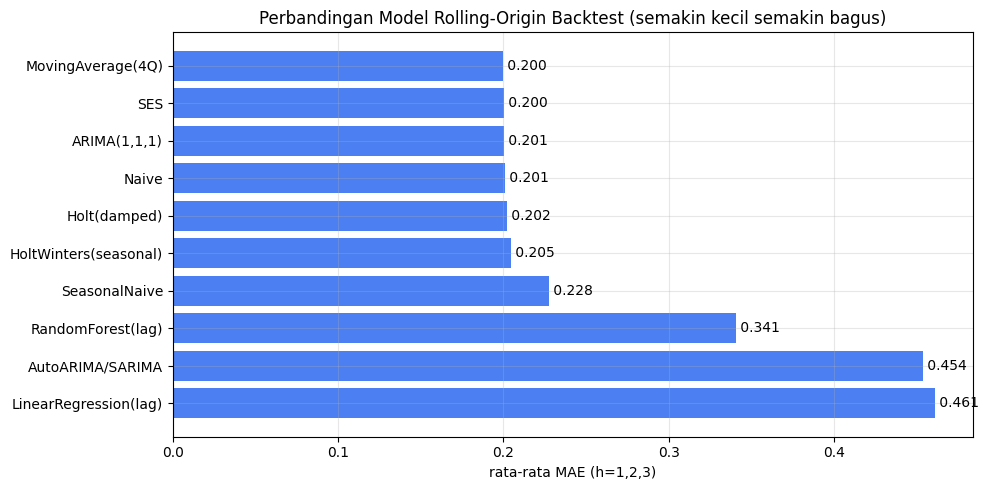

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
order = overall.index
ax.barh(order, overall.loc[order, 'MAE'], color='#4B7FF2')
ax.set_xlabel('rata-rata MAE (h=1,2,3)')
ax.set_title('Perbandingan Model Rolling-Origin Backtest (semakin kecil semakin bagus)')
ax.invert_yaxis()
for i, v in enumerate(overall.loc[order, 'MAE']):
    ax.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

**Insight dari backtest:**
- Model paling sederhana (Naive, Moving Average, SES) sangat kompetitif dibanding model yang lebih kompleks (ARIMA, Random Forest, Linear Regression), selisih MAE antar top model kecil.
- Model ML dengan lag features (Linear Regression, Random Forest)  performanya kurang bagus untuk h yang lebih jauh. Riskan overfit ke pola historis (termasuk shock COVID) dengan data sekecil ini.
- Model seasonal (Holt-Winters seasonal, Auto-SARIMA) tidak konsisten mengalahkan versi non-seasonal. Konsisten dengan temuan STL bahwa komponen musiman residual kecil.

Karena beberapa model top (Naive, SES, ARIMA(1,1,1), Holt damped) hasilnya sangat berdekatan, pilih final model berdasarkan kombinasi: akurasi backtest + kemampuan model memberi **confidence interval** yang proper (bukan cuma titik forecast). Jadi pakai **ARIMA(1,1,1)**.

## 6. Forecast Final Q2, Q3, Q4 2026

In [17]:
final_model = ARIMA(series, order=(1, 1, 1)).fit()
print(final_model.summary())

                               SARIMAX Results                                
Dep. Variable:             growth_pct   No. Observations:                   61
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -113.758
Date:                Tue, 07 Jul 2026   AIC                            233.517
Time:                        13:22:15   BIC                            239.800
Sample:                    03-31-2011   HQIC                           235.974
                         - 03-31-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2156      1.558     -0.138      0.890      -3.269       2.838
ma.L1          0.1163      1.551      0.075      0.940      -2.924       3.157
sigma2         2.5958      0.180     14.451      0.0

In [18]:
FORECAST_STEPS = 3
fc_res = final_model.get_forecast(steps=FORECAST_STEPS)
fc_mean = fc_res.predicted_mean
fc_ci80 = fc_res.conf_int(alpha=0.20)
fc_ci95 = fc_res.conf_int(alpha=0.05)

future_index = pd.period_range(df['period'].iloc[-1] + 1, periods=FORECAST_STEPS, freq='Q')
labels = [f"{p.year}Q{p.quarter}" for p in future_index]

forecast_table = pd.DataFrame({
    'kuartal': labels,
    'forecast_growth_pct': fc_mean.values.round(2),
    'lower_80%': fc_ci80.iloc[:, 0].values.round(2),
    'upper_80%': fc_ci80.iloc[:, 1].values.round(2),
    'lower_95%': fc_ci95.iloc[:, 0].values.round(2),
    'upper_95%': fc_ci95.iloc[:, 1].values.round(2),
})
forecast_table

,kuartal,forecast_growth_pct,lower_80%,upper_80%,lower_95%,upper_95%
0,2026Q2,5.59,3.53,7.66,2.43,8.75
1,2026Q3,5.60,2.82,8.37,1.35,9.85
2,2026Q4,5.60,2.23,8.96,0.44,10.75


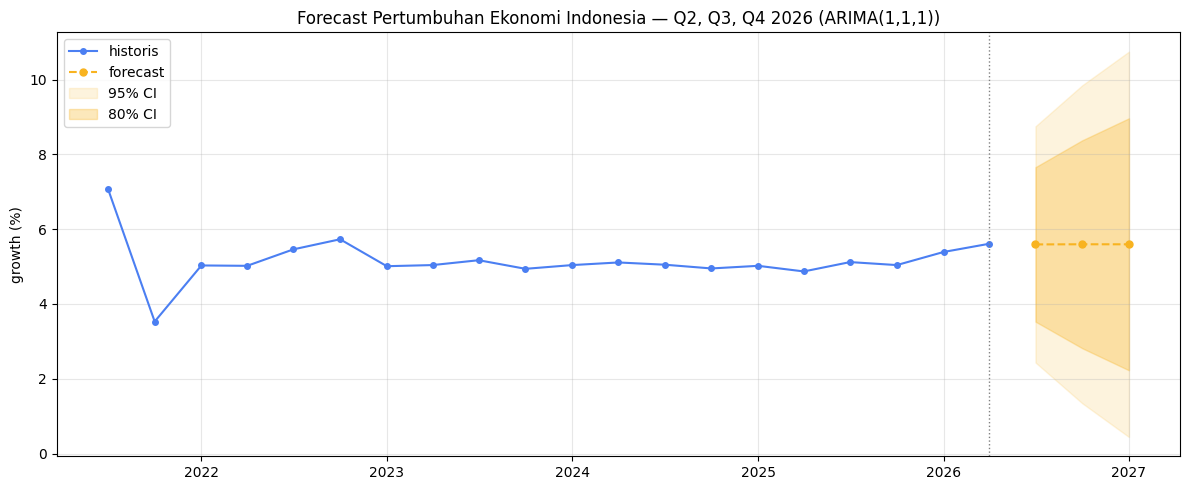

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

hist_plot = series.iloc[-20:]
ax.plot(hist_plot.index, hist_plot.values, marker='o', markersize=4, color='#4B7FF2', label='historis')

fc_x = fc_mean.index
ax.plot(fc_x, fc_mean.values, marker='o', markersize=5, color='#F8B320', linestyle='--', label='forecast')
ax.fill_between(fc_x, fc_ci95.iloc[:, 0], fc_ci95.iloc[:, 1], color='#F8B320', alpha=0.15, label='95% CI')
ax.fill_between(fc_x, fc_ci80.iloc[:, 0], fc_ci80.iloc[:, 1], color='#F8B320', alpha=0.3, label='80% CI')

ax.axvline(hist_plot.index[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title('Forecast Pertumbuhan Ekonomi Indonesia — Q2, Q3, Q4 2026 (ARIMA(1,1,1))')
ax.set_ylabel('growth (%)')
ax.legend()
plt.tight_layout()
plt.show()